# app

06 - Stage State Machine

Проверка технологической логики переходов между стадиями пайки.

Цель ноутбука:

1. Загрузить предсказания финальной нейросетевой модели.
2. Реализовать простую state machine для стадий пайки.
3. Сравнить raw predictions, temporal smoothing и state-machine predictions.
4. Проверить, уменьшаются ли ложные скачки стадий.
5. Подобрать параметры для дальнейшего использования в inference pipeline.


## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
from collections import Counter, deque
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## env

In [6]:
FPS = 10
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')
EXPERIMENT_NAME = f"final_neural_stage_classification_{FPS}"

In [7]:
REPORTS = ROOT / "reports" 
REPORTS_DIR = REPORTS / EXPERIMENT_NAME
FIGURES_DIR = REPORTS / "figures" / "stage_state_machine"
OUTPUT_DIR = REPORTS / "stage_state_machine"
PREDICTIONS_PATH = REPORTS_DIR / f"resnet18_base_test_predictions_{FPS}.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert PREDICTIONS_PATH.exists(), PREDICTIONS_PATH

In [8]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

STAGE_ORDER

['inactive_preparation', 'flux_activation', 'active_brazing', 'stabilization']

# lib

# model

# runtime

In [9]:
pred_df = pd.read_csv(PREDICTIONS_PATH)

print(pred_df.shape)
pred_df.head()

(1732, 11)


,video_id,frame_path,timestamp_s,stage_name,stage_id,pred_stage_id,pred_stage_name,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization
0,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.0,inactive_preparation,0,0,inactive_preparation,0.689079,0.167046,0.072961,0.070914
1,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.1,inactive_preparation,0,1,flux_activation,0.318643,0.434341,0.107281,0.139735
2,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.2,inactive_preparation,0,0,inactive_preparation,0.467962,0.320719,0.114499,0.096820
3,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.3,inactive_preparation,0,0,inactive_preparation,0.489105,0.242795,0.184225,0.083875
4,MVI_6265,data/processed/frames_10/MVI_6265/MVI_6265_000...,0.4,inactive_preparation,0,0,inactive_preparation,0.779270,0.067154,0.088990,0.064586


In [10]:
required_columns = {
    "video_id",
    "timestamp_s",
    "stage_id",
    "stage_name",
    "pred_stage_id",
    "pred_stage_name",
}

missing = required_columns - set(pred_df.columns)

if missing:
    raise ValueError(f"Missing columns: {missing}")

pred_df = pred_df.sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)

pred_df[["video_id", "timestamp_s", "stage_name", "pred_stage_name"]].head()

,video_id,timestamp_s,stage_name,pred_stage_name
0,MVI_6265,0.0,inactive_preparation,inactive_preparation
1,MVI_6265,0.1,inactive_preparation,flux_activation
2,MVI_6265,0.2,inactive_preparation,inactive_preparation
3,MVI_6265,0.3,inactive_preparation,inactive_preparation
4,MVI_6265,0.4,inactive_preparation,inactive_preparation


In [11]:
prob_columns = [f"prob_{stage}" for stage in STAGE_ORDER]
available_prob_columns = [col for col in prob_columns if col in pred_df.columns]

available_prob_columns

['prob_inactive_preparation',
 'prob_flux_activation',
 'prob_active_brazing',
 'prob_stabilization']

## evaluate

Raw neural predictions
--------------------------------------------------------------------------------
accuracy:    0.8747
macro_f1:    0.8209
weighted_f1: 0.8895

                      precision    recall  f1-score   support

inactive_preparation     0.9988    0.8480    0.9173      1000
     flux_activation     0.4255    0.9928    0.5957       138
      active_brazing     0.9926    0.6837    0.8097       196
       stabilization     0.9296    0.9950    0.9612       398

            accuracy                         0.8747      1732
           macro avg     0.8366    0.8799    0.8209      1732
        weighted avg     0.9365    0.8747    0.8895      1732



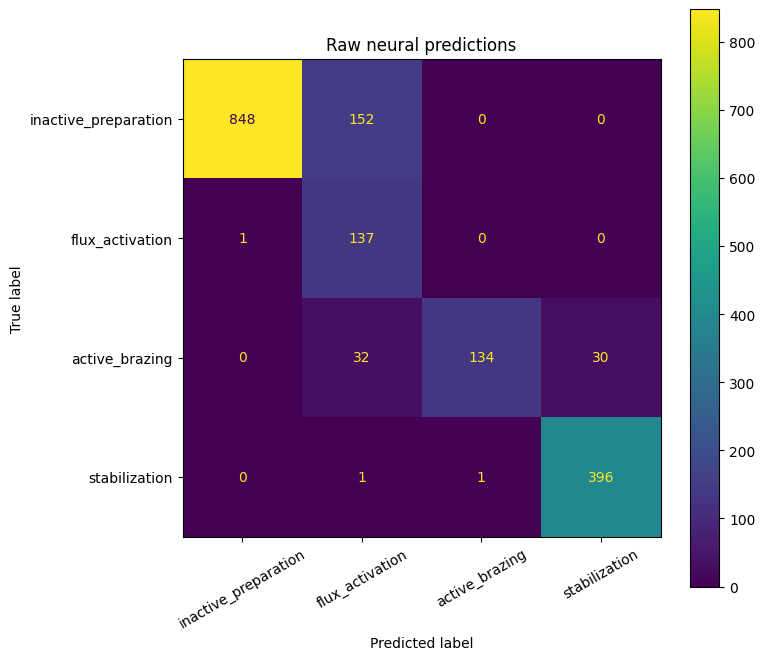

In [12]:
def evaluate_prediction_columns(
    df: pd.DataFrame,
    pred_col: str,
    title: str,
):
    y_true = df["stage_id"].to_numpy()
    y_pred = df[pred_col].to_numpy()

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(title)
    print("-" * 80)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro_f1:    {macro_f1:.4f}")
    print(f"weighted_f1: {weighted_f1:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm.tolist(),
    }


raw_metrics = evaluate_prediction_columns(
    pred_df,
    pred_col="pred_stage_id",
    title="Raw neural predictions",
)

## simple majority smoothing

Majority smoothing, window=5
--------------------------------------------------------------------------------
accuracy:    0.8776
macro_f1:    0.8290
weighted_f1: 0.8926

                      precision    recall  f1-score   support

inactive_preparation     0.9988    0.8440    0.9149      1000
     flux_activation     0.4281    0.9928    0.5983       138
      active_brazing     1.0000    0.7194    0.8368       196
       stabilization     0.9343    1.0000    0.9660       398

            accuracy                         0.8776      1732
           macro avg     0.8403    0.8890    0.8290      1732
        weighted avg     0.9386    0.8776    0.8926      1732



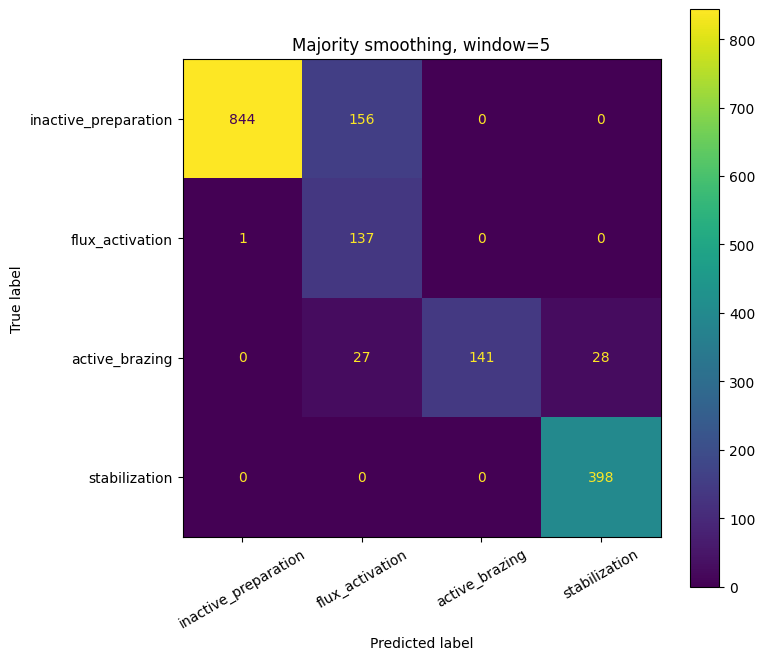

In [13]:
def smooth_majority_vote_for_video(
    video_df: pd.DataFrame,
    pred_col: str = "pred_stage_id",
    output_col: str = "pred_stage_id_smooth",
    window_size: int = 5,
) -> pd.DataFrame:
    video_df = video_df.sort_values("timestamp_s").copy()
    preds = video_df[pred_col].to_numpy()

    half = window_size // 2
    smoothed = []

    for i in range(len(preds)):
        left = max(0, i - half)
        right = min(len(preds), i + half + 1)

        window = preds[left:right]
        smoothed.append(Counter(window).most_common(1)[0][0])

    video_df[output_col] = smoothed
    video_df["pred_stage_name_smooth"] = video_df[output_col].map(ID_TO_STAGE)

    return video_df


SMOOTHING_WINDOW = 5

smooth_parts = []

for video_id, video_df in pred_df.groupby("video_id"):
    smooth_parts.append(
        smooth_majority_vote_for_video(
            video_df,
            pred_col="pred_stage_id",
            output_col="pred_stage_id_smooth",
            window_size=SMOOTHING_WINDOW,
        )
    )

smooth_df = pd.concat(smooth_parts).sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)

smooth_metrics = evaluate_prediction_columns(
    smooth_df,
    pred_col="pred_stage_id_smooth",
    title=f"Majority smoothing, window={SMOOTHING_WINDOW}",
)

## state machine v1

Простая state machine:

начинается с inactive_preparation;
стадии могут идти только вперёд;
переход на следующую стадию подтверждается только если модель предсказывает эту стадию min_confirm_frames раз в последних window_size кадрах;
переходы через стадию не разрешаются;
обратные переходы запрещены.

In [14]:
class BrazingStageStateMachine:
    def __init__(
        self,
        min_confirm_frames: int = 5,
        window_size: int = 7,
        confidence_threshold: float = 0.0,
        use_probabilities: bool = True,
    ):
        self.min_confirm_frames = min_confirm_frames
        self.window_size = window_size
        self.confidence_threshold = confidence_threshold
        self.use_probabilities = use_probabilities

        self.current_stage_id = 0
        self.history = deque(maxlen=window_size)

    def reset(self):
        self.current_stage_id = 0
        self.history.clear()

    def _get_confidence_for_stage(self, row: pd.Series, stage_id: int) -> float:
        stage_name = ID_TO_STAGE[stage_id]
        prob_col = f"prob_{stage_name}"

        if self.use_probabilities and prob_col in row.index:
            return float(row[prob_col])

        # Если вероятностей нет, используем confidence только для raw prediction,
        # либо считаем 1.0 для совпадающего pred.
        if "confidence" in row.index and int(row["pred_stage_id"]) == stage_id:
            return float(row["confidence"])

        return 1.0 if int(row["pred_stage_id"]) == stage_id else 0.0

    def update(self, row: pd.Series) -> int:
        raw_pred_id = int(row["pred_stage_id"])

        # Добавляем raw prediction в историю.
        self.history.append(raw_pred_id)

        # Уже на финальной стадии — остаёмся там.
        if self.current_stage_id == 3:
            return self.current_stage_id

        next_stage_id = self.current_stage_id + 1

        # Проверяем только следующий допустимый переход.
        num_next_stage_votes = sum(1 for x in self.history if x == next_stage_id)
        next_stage_confidence = self._get_confidence_for_stage(row, next_stage_id)

        if (
            num_next_stage_votes >= self.min_confirm_frames
            and next_stage_confidence >= self.confidence_threshold
        ):
            self.current_stage_id = next_stage_id

        return self.current_stage_id

### apply state machine

State machine confirm=5, window=7, conf=0.0
--------------------------------------------------------------------------------
accuracy:    0.8441
macro_f1:    0.7988
weighted_f1: 0.8674

                      precision    recall  f1-score   support

inactive_preparation     0.9888    0.7970    0.8826      1000
     flux_activation     0.3525    0.9348    0.5119       138
      active_brazing     0.9726    0.7245    0.8304       196
       stabilization     0.9517    0.9899    0.9704       398

            accuracy                         0.8441      1732
           macro avg     0.8164    0.8616    0.7988      1732
        weighted avg     0.9278    0.8441    0.8674      1732



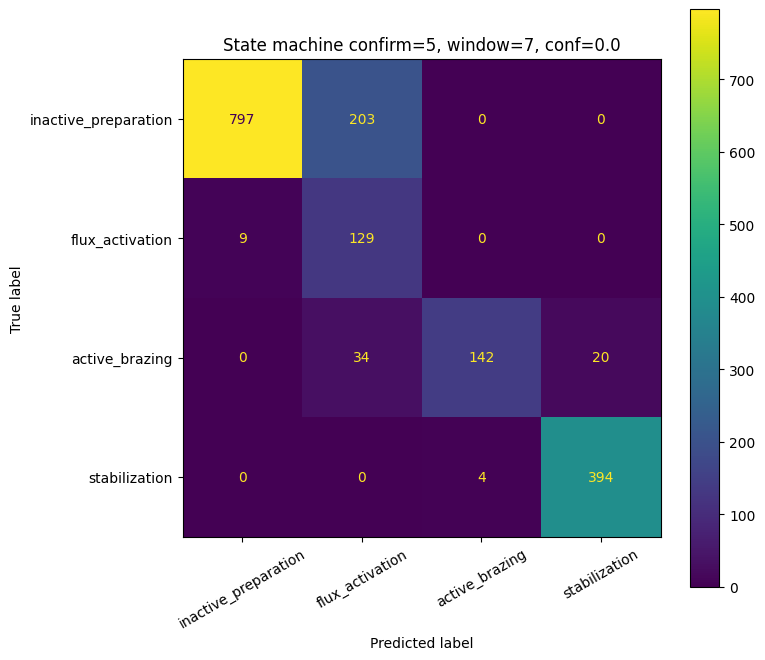

In [15]:
def apply_state_machine(
    df: pd.DataFrame,
    min_confirm_frames: int = 5,
    window_size: int = 7,
    confidence_threshold: float = 0.0,
    use_probabilities: bool = True,
) -> pd.DataFrame:
    parts = []

    for video_id, video_df in df.groupby("video_id"):
        video_df = video_df.sort_values("timestamp_s").copy()

        sm = BrazingStageStateMachine(
            min_confirm_frames=min_confirm_frames,
            window_size=window_size,
            confidence_threshold=confidence_threshold,
            use_probabilities=use_probabilities,
        )

        stable_stage_ids = []

        for _, row in video_df.iterrows():
            stable_stage_id = sm.update(row)
            stable_stage_ids.append(stable_stage_id)

        video_df["state_machine_stage_id"] = stable_stage_ids
        video_df["state_machine_stage_name"] = video_df["state_machine_stage_id"].map(ID_TO_STAGE)

        parts.append(video_df)

    return pd.concat(parts).sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)


SM_MIN_CONFIRM_FRAMES = 5
SM_WINDOW_SIZE = 7
SM_CONFIDENCE_THRESHOLD = 0.0

sm_df = apply_state_machine(
    pred_df,
    min_confirm_frames=SM_MIN_CONFIRM_FRAMES,
    window_size=SM_WINDOW_SIZE,
    confidence_threshold=SM_CONFIDENCE_THRESHOLD,
    use_probabilities=True,
)

sm_metrics = evaluate_prediction_columns(
    sm_df,
    pred_col="state_machine_stage_id",
    title=(
        f"State machine "
        f"confirm={SM_MIN_CONFIRM_FRAMES}, "
        f"window={SM_WINDOW_SIZE}, "
        f"conf={SM_CONFIDENCE_THRESHOLD}"
    ),
)

### compare metrics

In [16]:
metrics_comparison = pd.DataFrame([
    {
        "method": "raw",
        **{k: v for k, v in raw_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": f"majority_smoothing_w{SMOOTHING_WINDOW}",
        **{k: v for k, v in smooth_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": f"state_machine_c{SM_MIN_CONFIRM_FRAMES}_w{SM_WINDOW_SIZE}",
        **{k: v for k, v in sm_metrics.items() if k != "confusion_matrix"},
    },
])

metrics_comparison

,method,accuracy,macro_f1,weighted_f1
0,raw,0.874711,0.820934,0.889545
1,majority_smoothing_w5,0.877598,0.828993,0.892582
2,state_machine_c5_w7,0.844111,0.798843,0.867352


In [17]:
metrics_comparison.to_csv(
    OUTPUT_DIR / "state_machine_metrics_comparison.csv",
    index=False,
)

### timeline

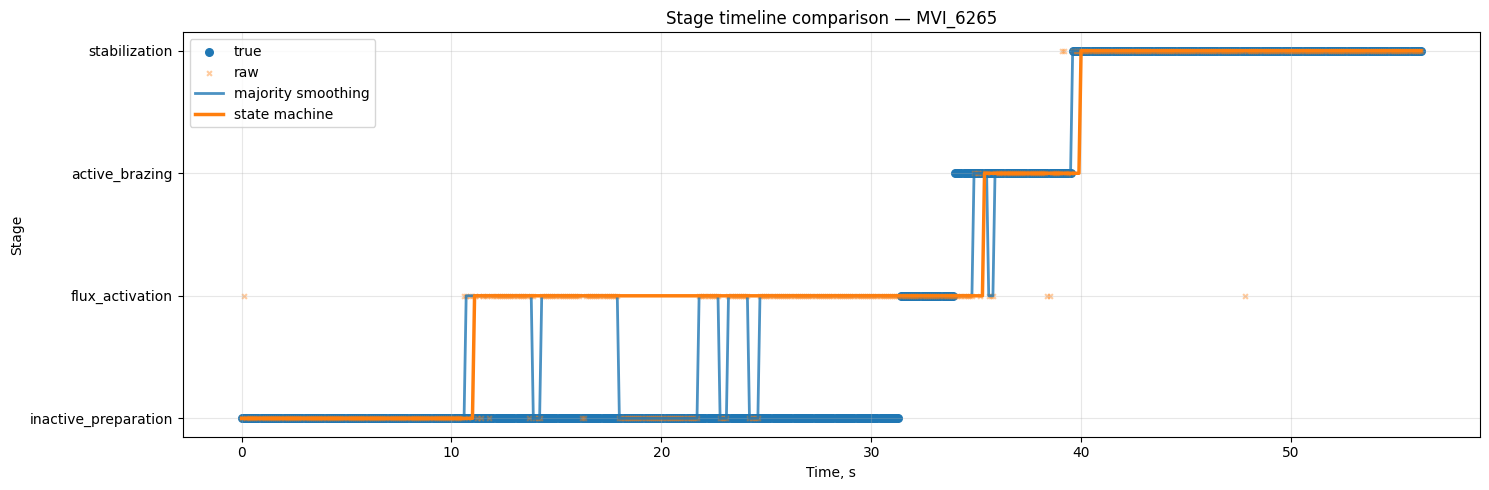

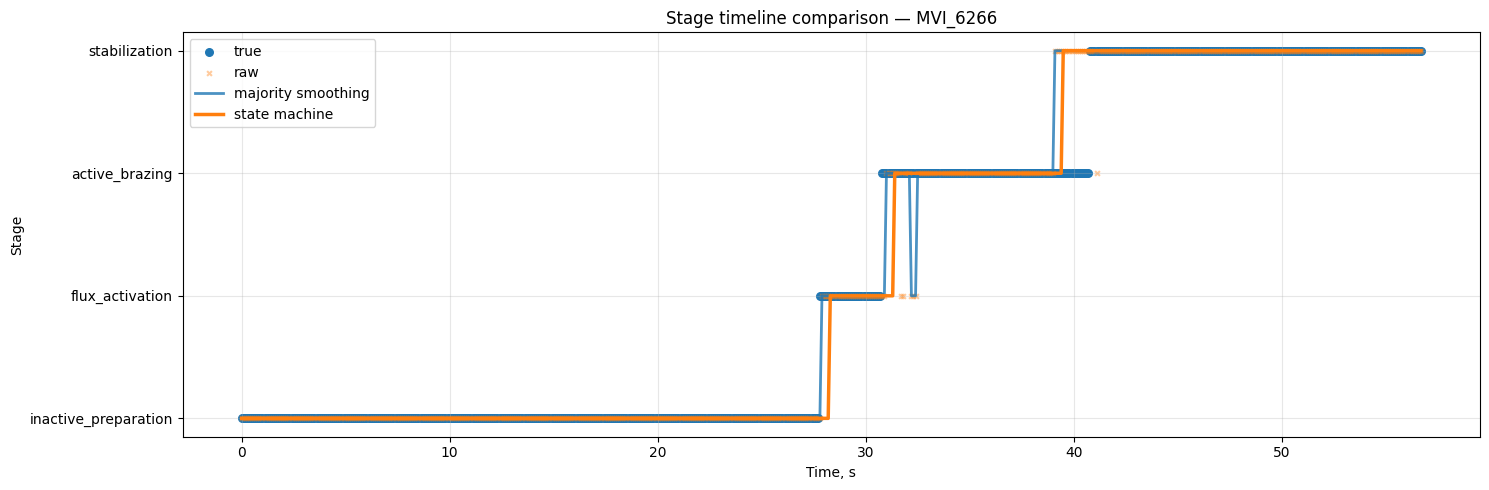

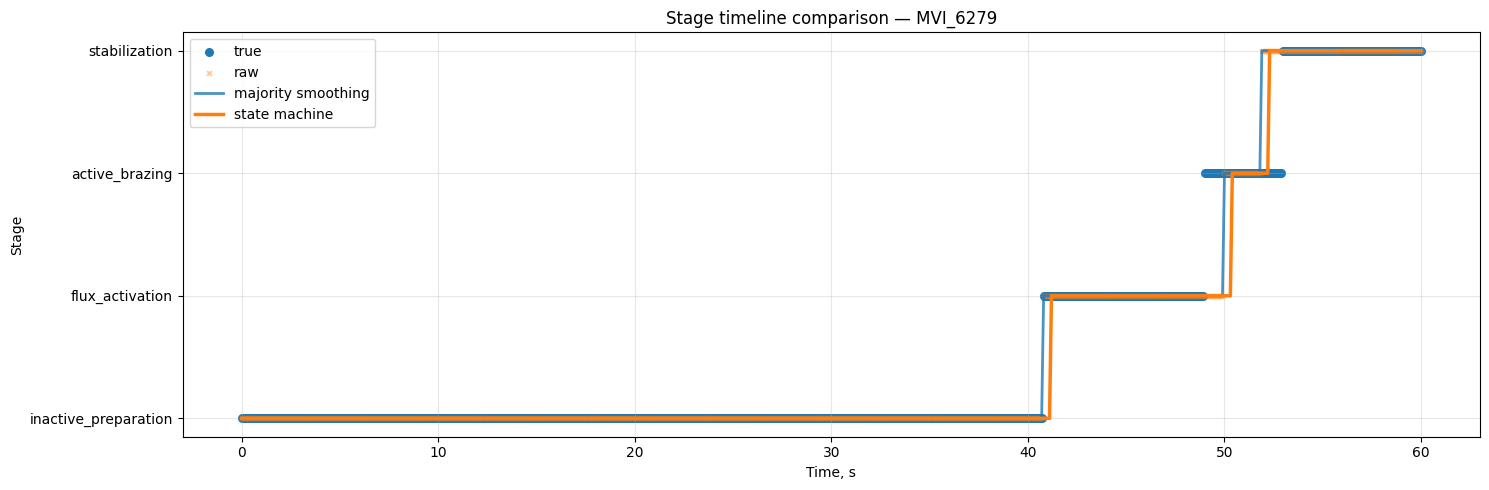

In [18]:
def plot_stage_timeline_comparison(
    df_raw: pd.DataFrame,
    df_smooth: pd.DataFrame,
    df_sm: pd.DataFrame,
    video_id: str,
):
    raw_video_df = df_raw[df_raw["video_id"] == video_id].sort_values("timestamp_s")
    smooth_video_df = df_smooth[df_smooth["video_id"] == video_id].sort_values("timestamp_s")
    sm_video_df = df_sm[df_sm["video_id"] == video_id].sort_values("timestamp_s")

    plt.figure(figsize=(15, 5))

    plt.scatter(
        raw_video_df["timestamp_s"],
        raw_video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        raw_video_df["timestamp_s"],
        raw_video_df["pred_stage_id"],
        s=12,
        label="raw",
        marker="x",
        alpha=0.4,
    )

    plt.plot(
        smooth_video_df["timestamp_s"],
        smooth_video_df["pred_stage_id_smooth"],
        label="majority smoothing",
        linewidth=2,
        alpha=0.8,
    )

    plt.plot(
        sm_video_df["timestamp_s"],
        sm_video_df["state_machine_stage_id"],
        label="state machine",
        linewidth=2.5,
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"Stage timeline comparison — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_state_machine_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for video_id in sorted(pred_df["video_id"].unique()):
    plot_stage_timeline_comparison(
        pred_df,
        smooth_df,
        sm_df,
        video_id,
    )

### transition time analysis

In [19]:
def extract_transition_times(
    df: pd.DataFrame,
    stage_col: str,
) -> pd.DataFrame:
    rows = []

    for video_id, video_df in df.groupby("video_id"):
        video_df = video_df.sort_values("timestamp_s").copy()

        stages = video_df[stage_col].to_numpy()
        times = video_df["timestamp_s"].to_numpy()

        transition_info = {
            "video_id": video_id,
        }

        for stage_id in [1, 2, 3]:
            idx = np.where(stages == stage_id)[0]

            if len(idx) == 0:
                transition_info[f"first_{ID_TO_STAGE[stage_id]}_s"] = np.nan
            else:
                transition_info[f"first_{ID_TO_STAGE[stage_id]}_s"] = float(times[idx[0]])

        rows.append(transition_info)

    return pd.DataFrame(rows)


true_transitions = extract_transition_times(pred_df, "stage_id")
raw_transitions = extract_transition_times(pred_df, "pred_stage_id")
smooth_transitions = extract_transition_times(smooth_df, "pred_stage_id_smooth")
sm_transitions = extract_transition_times(sm_df, "state_machine_stage_id")

true_transitions

,video_id,first_flux_activation_s,first_active_brazing_s,first_stabilization_s
0,MVI_6265,31.4,34.0,39.6
1,MVI_6266,27.8,30.8,40.8
2,MVI_6279,40.8,49.0,53.0


### compare transition times

In [20]:
def add_prefix_except_video(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    renamed = {}
    for col in df.columns:
        if col != "video_id":
            renamed[col] = f"{prefix}_{col}"
    return df.rename(columns=renamed)


transition_compare = true_transitions.copy()

transition_compare = transition_compare.merge(
    add_prefix_except_video(raw_transitions, "raw"),
    on="video_id",
)

transition_compare = transition_compare.merge(
    add_prefix_except_video(smooth_transitions, "smooth"),
    on="video_id",
)

transition_compare = transition_compare.merge(
    add_prefix_except_video(sm_transitions, "sm"),
    on="video_id",
)

transition_compare

,video_id,first_flux_activation_s,first_active_brazing_s,first_stabilization_s,raw_first_flux_activation_s,raw_first_active_brazing_s,raw_first_stabilization_s,smooth_first_flux_activation_s,smooth_first_active_brazing_s,smooth_first_stabilization_s,sm_first_flux_activation_s,sm_first_active_brazing_s,sm_first_stabilization_s
0,MVI_6265,31.4,34.0,39.6,0.1,34.9,39.1,10.7,34.9,39.6,11.1,35.4,40.0
1,MVI_6266,27.8,30.8,40.8,27.9,31.0,39.1,27.9,31.0,39.1,28.3,31.4,39.5
2,MVI_6279,40.8,49.0,53.0,40.8,50.0,51.9,40.8,50.0,51.9,41.2,50.4,52.3


In [21]:
for stage_name in ["flux_activation", "active_brazing", "stabilization"]:
    true_col = f"first_{stage_name}_s"

    for method in ["raw", "smooth", "sm"]:
        pred_col = f"{method}_first_{stage_name}_s"
        err_col = f"{method}_{stage_name}_error_s"

        transition_compare[err_col] = (
            transition_compare[pred_col] - transition_compare[true_col]
        )

transition_compare

,video_id,first_flux_activation_s,first_active_brazing_s,first_stabilization_s,raw_first_flux_activation_s,raw_first_active_brazing_s,raw_first_stabilization_s,smooth_first_flux_activation_s,smooth_first_active_brazing_s,smooth_first_stabilization_s,...,sm_first_stabilization_s,raw_flux_activation_error_s,smooth_flux_activation_error_s,sm_flux_activation_error_s,raw_active_brazing_error_s,smooth_active_brazing_error_s,sm_active_brazing_error_s,raw_stabilization_error_s,smooth_stabilization_error_s,sm_stabilization_error_s
0,MVI_6265,31.4,34.0,39.6,0.1,34.9,39.1,10.7,34.9,39.6,...,40.0,-31.3,-20.7,-20.3,0.9,0.9,1.4,-0.5,0.0,0.4
1,MVI_6266,27.8,30.8,40.8,27.9,31.0,39.1,27.9,31.0,39.1,...,39.5,0.1,0.1,0.5,0.2,0.2,0.6,-1.7,-1.7,-1.3
2,MVI_6279,40.8,49.0,53.0,40.8,50.0,51.9,40.8,50.0,51.9,...,52.3,0.0,0.0,0.4,1.0,1.0,1.4,-1.1,-1.1,-0.7


In [22]:
transition_compare.to_csv(
    OUTPUT_DIR / "state_machine_transition_times.csv",
    index=False,
)

transition_compare

,video_id,first_flux_activation_s,first_active_brazing_s,first_stabilization_s,raw_first_flux_activation_s,raw_first_active_brazing_s,raw_first_stabilization_s,smooth_first_flux_activation_s,smooth_first_active_brazing_s,smooth_first_stabilization_s,...,sm_first_stabilization_s,raw_flux_activation_error_s,smooth_flux_activation_error_s,sm_flux_activation_error_s,raw_active_brazing_error_s,smooth_active_brazing_error_s,sm_active_brazing_error_s,raw_stabilization_error_s,smooth_stabilization_error_s,sm_stabilization_error_s
0,MVI_6265,31.4,34.0,39.6,0.1,34.9,39.1,10.7,34.9,39.6,...,40.0,-31.3,-20.7,-20.3,0.9,0.9,1.4,-0.5,0.0,0.4
1,MVI_6266,27.8,30.8,40.8,27.9,31.0,39.1,27.9,31.0,39.1,...,39.5,0.1,0.1,0.5,0.2,0.2,0.6,-1.7,-1.7,-1.3
2,MVI_6279,40.8,49.0,53.0,40.8,50.0,51.9,40.8,50.0,51.9,...,52.3,0.0,0.0,0.4,1.0,1.0,1.4,-1.1,-1.1,-0.7


### grid search

In [23]:
grid_rows = []

for min_confirm_frames in [3, 5, 7, 10, 15]:
    for window_size in [5, 7, 10, 15, 20]:
        if min_confirm_frames > window_size:
            continue

        candidate_df = apply_state_machine(
            pred_df,
            min_confirm_frames=min_confirm_frames,
            window_size=window_size,
            confidence_threshold=0.0,
            use_probabilities=True,
        )

        y_true = candidate_df["stage_id"].to_numpy()
        y_pred = candidate_df["state_machine_stage_id"].to_numpy()

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3],
            target_names=STAGE_ORDER,
            output_dict=True,
            zero_division=0,
        )

        grid_rows.append({
            "min_confirm_frames": min_confirm_frames,
            "window_size": window_size,
            "accuracy": accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
            "flux_activation_f1": report["flux_activation"]["f1-score"],
            "active_brazing_f1": report["active_brazing"]["f1-score"],
            "active_brazing_recall": report["active_brazing"]["recall"],
        })

grid_df = pd.DataFrame(grid_rows).sort_values(
    ["macro_f1", "active_brazing_f1"],
    ascending=False,
)

grid_df.head(20)

,min_confirm_frames,window_size,accuracy,macro_f1,weighted_f1,flux_activation_f1,active_brazing_f1,active_brazing_recall
1,3,7,0.849307,0.808333,0.871449,0.528827,0.850440,0.739796
2,3,10,0.849307,0.808333,0.871449,0.528827,0.850440,0.739796
3,3,15,0.849307,0.808333,0.871449,0.528827,0.850440,0.739796
4,3,20,0.849307,0.808333,0.871449,0.528827,0.850440,0.739796
0,3,5,0.848152,0.806464,0.870309,0.528827,0.845481,0.739796
7,5,10,0.845266,0.800696,0.868486,0.511905,0.835294,0.724490
8,5,15,0.845266,0.800696,0.868486,0.511905,0.835294,0.724490
9,5,20,0.845266,0.800696,0.868486,0.511905,0.835294,0.724490
6,5,7,0.844111,0.798843,0.867352,0.511905,0.830409,0.724490
5,5,5,0.845843,0.793550,0.868277,0.514970,0.798799,0.678571


In [24]:
grid_df.to_csv(
    OUTPUT_DIR / "state_machine_grid_search.csv",
    index=False,
)

### best state machine

In [25]:
best_sm_params = grid_df.iloc[0].to_dict()
best_sm_params

{'min_confirm_frames': 3.0,
 'window_size': 7.0,
 'accuracy': 0.8493071593533488,
 'macro_f1': 0.8083329902804284,
 'weighted_f1': 0.8714485571980656,
 'flux_activation_f1': 0.5288270377733598,
 'active_brazing_f1': 0.8504398826979472,
 'active_brazing_recall': 0.7397959183673469}

Best state machine confirm=3, window=7
--------------------------------------------------------------------------------
accuracy:    0.8493
macro_f1:    0.8083
weighted_f1: 0.8714

                      precision    recall  f1-score   support

inactive_preparation     0.9938    0.7950    0.8833      1000
     flux_activation     0.3644    0.9638    0.5288       138
      active_brazing     1.0000    0.7398    0.8504       196
       stabilization     0.9431    1.0000    0.9707       398

            accuracy                         0.8493      1732
           macro avg     0.8253    0.8746    0.8083      1732
        weighted avg     0.9327    0.8493    0.8714      1732



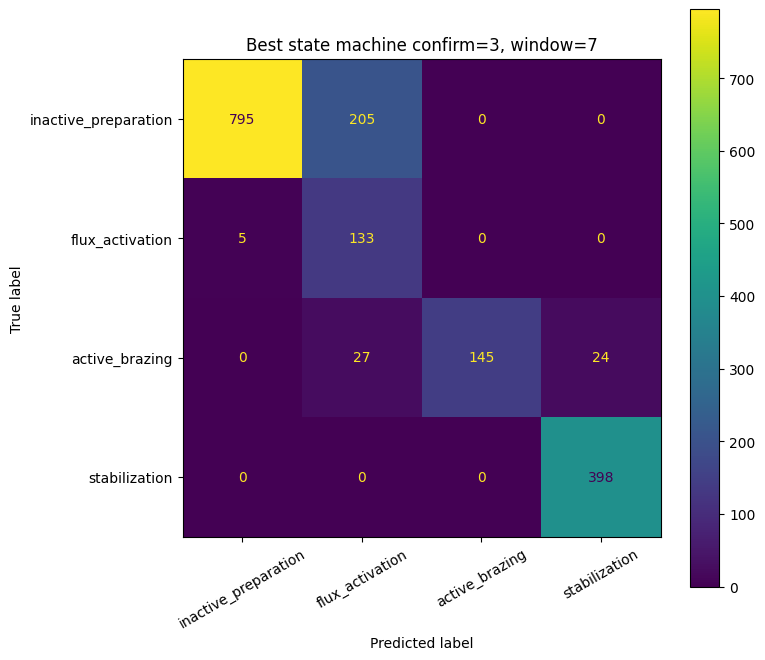

In [26]:
best_sm_df = apply_state_machine(
    pred_df,
    min_confirm_frames=int(best_sm_params["min_confirm_frames"]),
    window_size=int(best_sm_params["window_size"]),
    confidence_threshold=0.0,
    use_probabilities=True,
)

best_sm_metrics = evaluate_prediction_columns(
    best_sm_df,
    pred_col="state_machine_stage_id",
    title=(
        f"Best state machine "
        f"confirm={int(best_sm_params['min_confirm_frames'])}, "
        f"window={int(best_sm_params['window_size'])}"
    ),
)

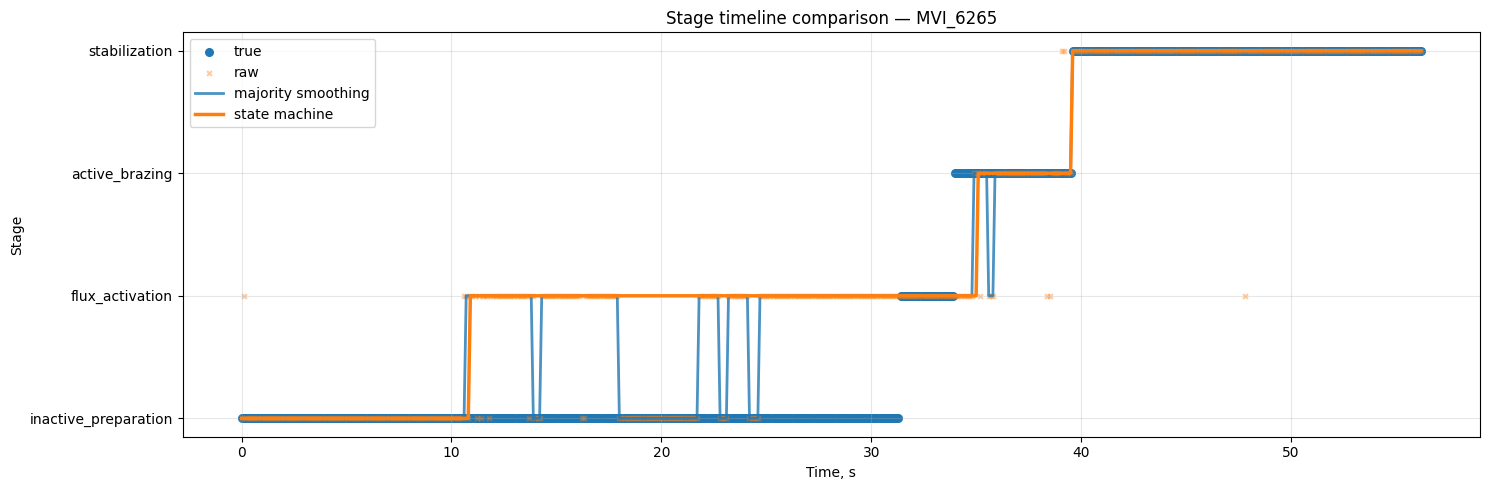

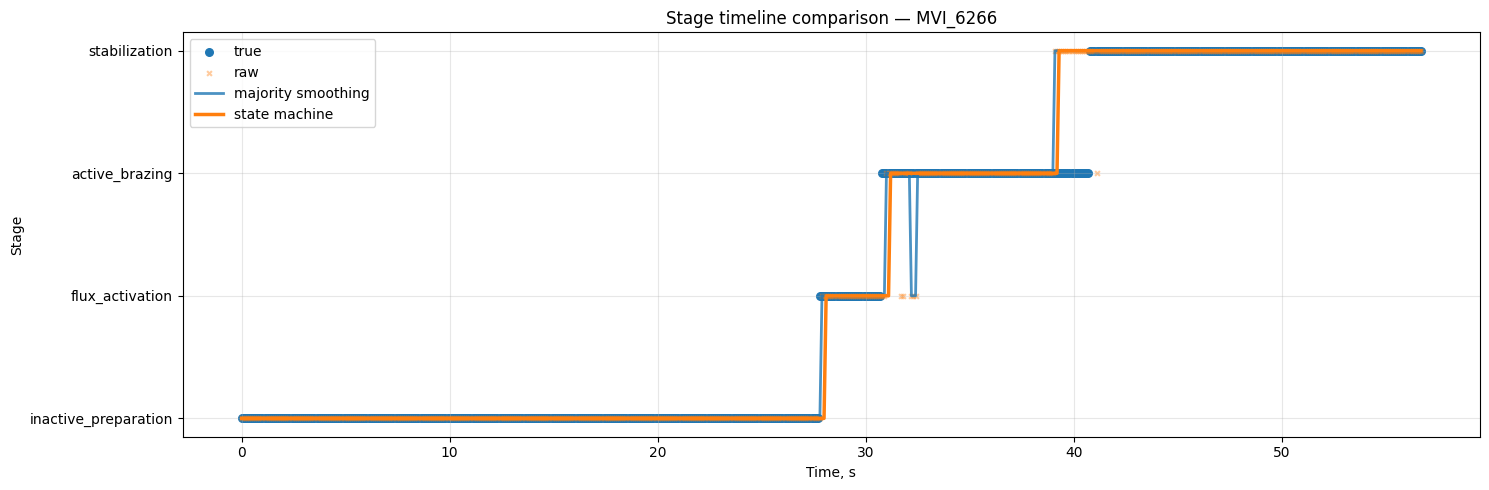

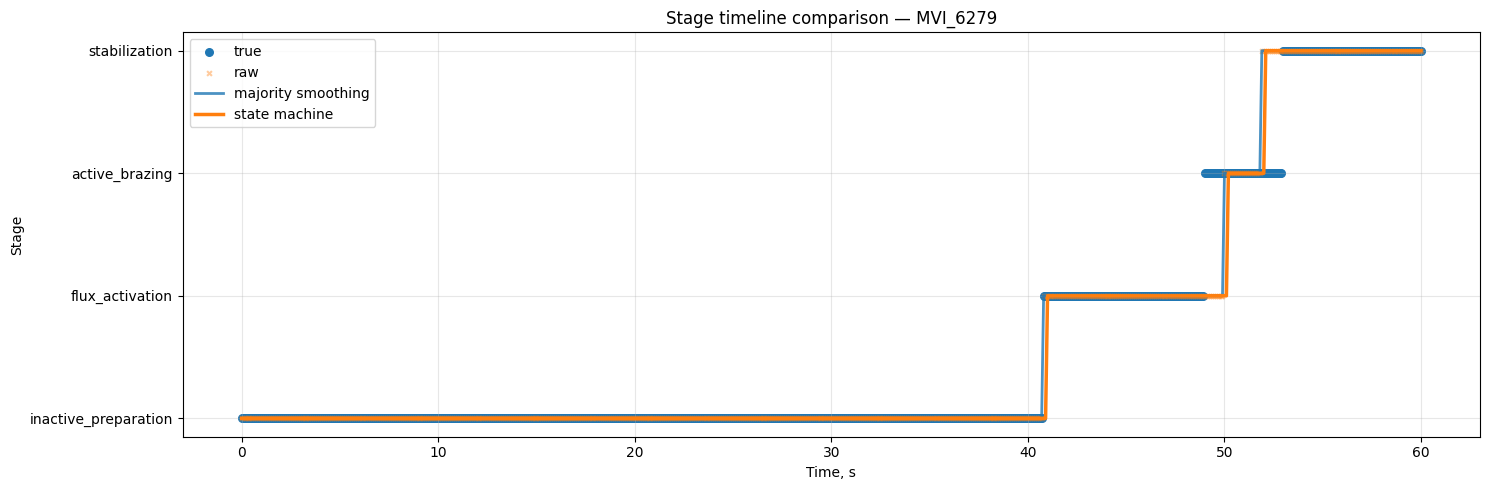

In [27]:
for video_id in sorted(pred_df["video_id"].unique()):
    plot_stage_timeline_comparison(
        pred_df,
        smooth_df,
        best_sm_df,
        video_id,
    )

### save config

In [28]:
final_state_machine_config = {
    "stage_order": STAGE_ORDER,
    "allowed_sequence": STAGE_ORDER,
    "min_confirm_frames": int(best_sm_params["min_confirm_frames"]),
    "window_size": int(best_sm_params["window_size"]),
    "confidence_threshold": 0.0,
    "use_probabilities": True,
    "fps": FPS,
    "notes": [
        "State machine selected using 10 FPS test predictions.",
        "Transitions are allowed only to the next stage.",
        "Backward transitions are forbidden.",
        "A transition is confirmed after enough votes for the next stage in the recent window.",
    ],
}

with open(OUTPUT_DIR / "state_machine_config.json", "w", encoding="utf-8") as f:
    json.dump(final_state_machine_config, f, ensure_ascii=False, indent=2)

final_state_machine_config

{'stage_order': ['inactive_preparation',
  'flux_activation',
  'active_brazing',
  'stabilization'],
 'allowed_sequence': ['inactive_preparation',
  'flux_activation',
  'active_brazing',
  'stabilization'],
 'min_confirm_frames': 3,
 'window_size': 7,
 'confidence_threshold': 0.0,
 'use_probabilities': True,
 'fps': 10,
 'notes': ['State machine selected using 10 FPS test predictions.',
  'Transitions are allowed only to the next stage.',
  'Backward transitions are forbidden.',
  'A transition is confirmed after enough votes for the next stage in the recent window.']}

### kick MVI_6265

In [50]:
HARD_CASE_VIDEOS = ["MVI_6265"]

def exclude_videos(df: pd.DataFrame, videos_to_exclude: list[str]) -> pd.DataFrame:
    return df[~df["video_id"].isin(videos_to_exclude)].copy().reset_index(drop=True)


pred_df_no_hard = exclude_videos(pred_df, HARD_CASE_VIDEOS)
smooth_df_no_hard = exclude_videos(smooth_df, HARD_CASE_VIDEOS)
sm_df_no_hard = exclude_videos(sm_df, HARD_CASE_VIDEOS)

print("Original videos:", sorted(pred_df["video_id"].unique()))
print("Without hard-case videos:", sorted(pred_df_no_hard["video_id"].unique()))

print("Original frames:", len(pred_df))
print("Frames without hard-case:", len(pred_df_no_hard))

Original videos: ['MVI_6265', 'MVI_6266', 'MVI_6279']
Without hard-case videos: ['MVI_6266', 'MVI_6279']
Original frames: 1732
Frames without hard-case: 1169


Raw neural predictions — without hard-case MVI_6265
--------------------------------------------------------------------------------
accuracy:    0.9598
macro_f1:    0.9175
weighted_f1: 0.9573

                      precision    recall  f1-score   support

inactive_preparation     0.9985    1.0000    0.9993       686
     flux_activation     0.8672    0.9911    0.9250       112
      active_brazing     0.9896    0.6786    0.8051       140
       stabilization     0.8915    0.9957    0.9407       231

            accuracy                         0.9598      1169
           macro avg     0.9367    0.9163    0.9175      1169
        weighted avg     0.9637    0.9598    0.9573      1169



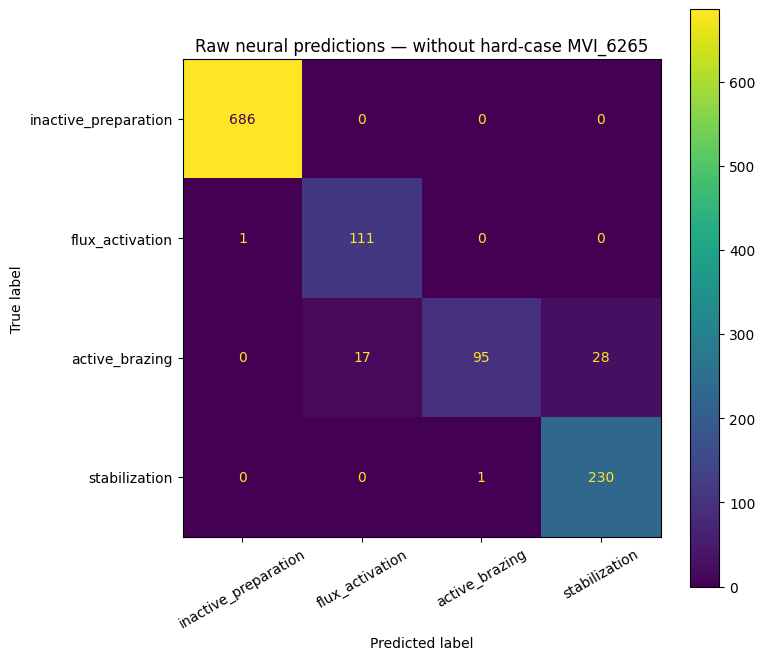

Majority smoothing, window=5 — without hard-case MVI_6265
--------------------------------------------------------------------------------
accuracy:    0.9624
macro_f1:    0.9234
weighted_f1: 0.9601

                      precision    recall  f1-score   support

inactive_preparation     0.9985    1.0000    0.9993       686
     flux_activation     0.8810    0.9911    0.9328       112
      active_brazing     1.0000    0.6929    0.8186       140
       stabilization     0.8919    1.0000    0.9429       231

            accuracy                         0.9624      1169
           macro avg     0.9428    0.9210    0.9234      1169
        weighted avg     0.9664    0.9624    0.9601      1169



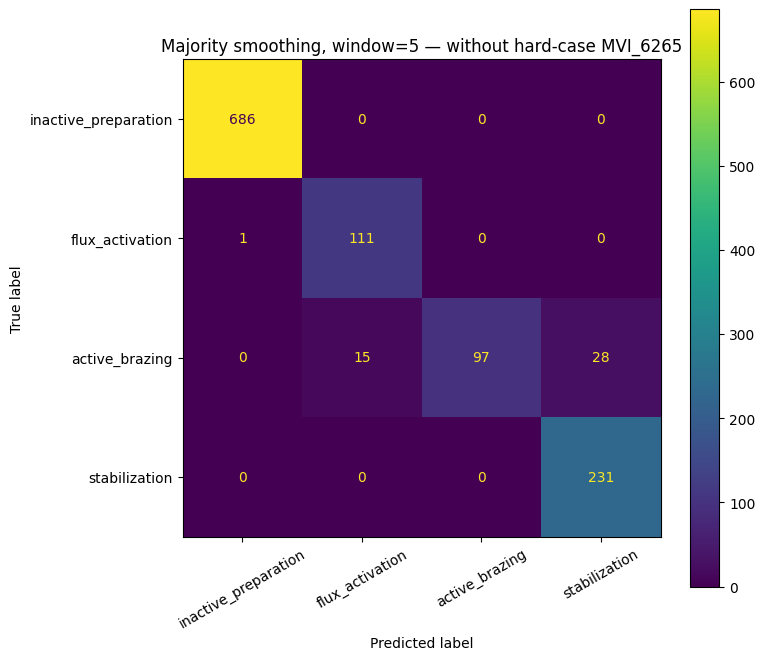

State machine v1, confirm=5, window=7 — without hard-case MVI_6265
--------------------------------------------------------------------------------
accuracy:    0.9581
macro_f1:    0.9155
weighted_f1: 0.9562

                      precision    recall  f1-score   support

inactive_preparation     0.9871    1.0000    0.9935       686
     flux_activation     0.8374    0.9196    0.8766       112
      active_brazing     1.0000    0.7143    0.8333       140
       stabilization     0.9203    1.0000    0.9585       231

            accuracy                         0.9581      1169
           macro avg     0.9362    0.9085    0.9155      1169
        weighted avg     0.9611    0.9581    0.9562      1169



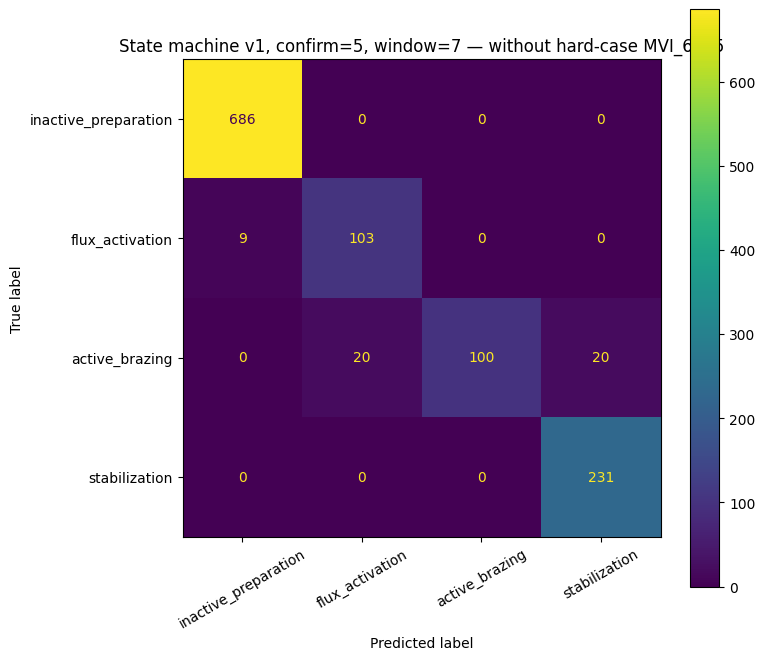

In [51]:
raw_metrics_no_hard = evaluate_prediction_columns(
    pred_df_no_hard,
    pred_col="pred_stage_id",
    title="Raw neural predictions — without hard-case MVI_6265",
)

smooth_metrics_no_hard = evaluate_prediction_columns(
    smooth_df_no_hard,
    pred_col="pred_stage_id_smooth",
    title=f"Majority smoothing, window={SMOOTHING_WINDOW} — without hard-case MVI_6265",
)

sm_metrics_no_hard = evaluate_prediction_columns(
    sm_df_no_hard,
    pred_col="state_machine_stage_id",
    title=(
        f"State machine v1, confirm={SM_MIN_CONFIRM_FRAMES}, "
        f"window={SM_WINDOW_SIZE} — without hard-case MVI_6265"
    ),
)

In [52]:
metrics_comparison_no_hard = pd.DataFrame([
    {
        "method": "raw_no_hard",
        **{k: v for k, v in raw_metrics_no_hard.items() if k != "confusion_matrix"},
    },
    {
        "method": f"majority_smoothing_w{SMOOTHING_WINDOW}_no_hard",
        **{k: v for k, v in smooth_metrics_no_hard.items() if k != "confusion_matrix"},
    },
    {
        "method": f"state_machine_v1_c{SM_MIN_CONFIRM_FRAMES}_w{SM_WINDOW_SIZE}_no_hard",
        **{k: v for k, v in sm_metrics_no_hard.items() if k != "confusion_matrix"},
    },
])

metrics_comparison_no_hard

,method,accuracy,macro_f1,weighted_f1
0,raw_no_hard,0.959795,0.917513,0.957325
1,majority_smoothing_w5_no_hard,0.962361,0.923367,0.960111
2,state_machine_v1_c5_w7_no_hard,0.958084,0.915480,0.956193


In [53]:
metrics_comparison_no_hard.to_csv(
    OUTPUT_DIR / "state_machine_metrics_without_hard_cases.csv",
    index=False,
)

In [54]:
def get_error_pairs(df: pd.DataFrame, pred_col: str, pred_name_col: str | None = None):
    tmp = df.copy()

    if pred_name_col is None:
        pred_name_col = f"{pred_col}_name"
        tmp[pred_name_col] = tmp[pred_col].map(ID_TO_STAGE)

    errors = tmp[tmp["stage_id"] != tmp[pred_col]].copy()

    return (
        errors
        .groupby(["stage_name", pred_name_col])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )


sm_error_pairs_no_hard = get_error_pairs(
    sm_df_no_hard,
    pred_col="state_machine_stage_id",
    pred_name_col="state_machine_stage_name",
)

sm_error_pairs_no_hard

,stage_name,state_machine_stage_name,count
0,active_brazing,flux_activation,20
1,active_brazing,stabilization,20
2,flux_activation,inactive_preparation,9


После исключения hard-case видео `MVI_6265` оценка отражает работу системы на более штатных видеозаписях процесса. Такой анализ не является заменой полной оценки, но позволяет отделить поведение алгоритма на нормальных примерах от поведения на сложном видео с нестабильной видимостью флюса и засветами.

`MVI_6265` следует рассматривать не как ошибку датасета, а как отдельный сложный сценарий, полезный для анализа устойчивости модели. На нём визуальные признаки флюса неоднократно меняются из-за засветов, что провоцирует преждевременные переходы state machine в `flux_activation`.

Основная оценка без `MVI_6265` показывает качество системы на более типичных видео, а отдельный анализ `MVI_6265` показывает ограничение текущего подхода и направление для будущей доработки.

### results

В данном ноутбуке была проверена технологическая логика переходов между стадиями пайки поверх предсказаний финальной нейросетевой модели. State machine учитывала допустимую последовательность процесса:

```text
inactive_preparation → flux_activation → active_brazing → stabilization
````

Сравнивались три варианта постобработки:

```text
raw neural predictions
majority-vote temporal smoothing
state machine
```

Итоговые метрики:

```text
raw:
accuracy:    0.8747
macro_f1:    0.8209
weighted_f1: 0.8895

majority smoothing:
accuracy:    0.8776
macro_f1:    0.8290
weighted_f1: 0.8926

best state machine:
accuracy:    0.8493
macro_f1:    0.8083
weighted_f1: 0.8714
```

По общим метрикам лучшим вариантом осталось простое временное сглаживание. State machine в текущей реализации уступила smoothing по accuracy, macro-F1 и weighted-F1.

При этом state machine дала положительный эффект для стадии `active_brazing`:

```text
active_brazing recall = 0.7398
active_brazing f1     = 0.8504
```

Это выше, чем у raw-предсказаний и majority smoothing. Следовательно, технологическая логика переходов может быть полезна для удержания стадии активной пайки и уменьшения кратковременных скачков на границах.

Основная проблема текущей state machine связана с ранним ложным переходом в `flux_activation`. На видео `MVI_6265` модель даёт ранние ложные предсказания `flux_activation`, после чего state machine фиксирует переход и уже не может вернуться назад. В результате переход `inactive_preparation → flux_activation` происходит существенно раньше истинной разметки.

## state machine v2

In [43]:
class BrazingStageStateMachineV2:
    def __init__(self, transition_rules: dict, initial_stage_id: int = 0):
        self.transition_rules = transition_rules
        self.initial_stage_id = initial_stage_id
        self.current_stage_id = initial_stage_id

        max_window = max(rule["window_size"] for rule in transition_rules.values())
        self.history = deque(maxlen=max_window)

    def reset(self):
        self.current_stage_id = self.initial_stage_id
        self.history.clear()

    def _prob_col(self, stage_id: int) -> str:
        return f"prob_{ID_TO_STAGE[stage_id]}"

    def _get_stage_prob(self, row: pd.Series, stage_id: int) -> float:
        col = self._prob_col(stage_id)

        if col in row.index:
            return float(row[col])

        if int(row["pred_stage_id"]) == stage_id:
            if "confidence" in row.index:
                return float(row["confidence"])
            return 1.0

        return 0.0

    def update(self, row: pd.Series) -> int:
        raw_pred_id = int(row["pred_stage_id"])

        probs = {
            stage_id: self._get_stage_prob(row, stage_id)
            for stage_id in [0, 1, 2, 3]
        }

        self.history.append({
            "pred_stage_id": raw_pred_id,
            "probs": probs,
        })

        if self.current_stage_id == 3:
            return self.current_stage_id

        next_stage_id = self.current_stage_id + 1
        rule = self.transition_rules.get((self.current_stage_id, next_stage_id))

        if rule is None:
            return self.current_stage_id

        recent = list(self.history)[-rule["window_size"]:]

        next_votes = sum(
            1 for item in recent
            if item["pred_stage_id"] == next_stage_id
        )

        mean_next_prob = float(np.mean([
            item["probs"][next_stage_id]
            for item in recent
        ]))

        current_next_prob = probs[next_stage_id]

        can_transition = (
            next_votes >= rule["min_confirm_frames"]
            and mean_next_prob >= rule["min_mean_prob"]
            and current_next_prob >= rule["min_current_prob"]
        )

        if can_transition:
            self.current_stage_id = next_stage_id

        return self.current_stage_id

In [44]:
def apply_state_machine_v2(
    df: pd.DataFrame,
    transition_rules: dict,
) -> pd.DataFrame:
    parts = []

    for video_id, video_df in df.groupby("video_id"):
        video_df = video_df.sort_values("timestamp_s").copy()

        sm = BrazingStageStateMachineV2(
            transition_rules=transition_rules,
            initial_stage_id=0,
        )

        stable_stage_ids = []

        for _, row in video_df.iterrows():
            stable_stage_ids.append(sm.update(row))

        video_df["state_machine_v2_stage_id"] = stable_stage_ids
        video_df["state_machine_v2_stage_name"] = (
            video_df["state_machine_v2_stage_id"].map(ID_TO_STAGE)
        )

        parts.append(video_df)

    return pd.concat(parts).sort_values(["video_id", "timestamp_s"]).reset_index(drop=True)

State machine v2
--------------------------------------------------------------------------------
accuracy:    0.8528
macro_f1:    0.8024
weighted_f1: 0.8735

                      precision    recall  f1-score   support

inactive_preparation     0.9727    0.8200    0.8899      1000
     flux_activation     0.3517    0.8333    0.4946       138
      active_brazing     0.9800    0.7500    0.8497       196
       stabilization     0.9587    0.9925    0.9753       398

            accuracy                         0.8528      1732
           macro avg     0.8158    0.8489    0.8024      1732
        weighted avg     0.9208    0.8528    0.8735      1732



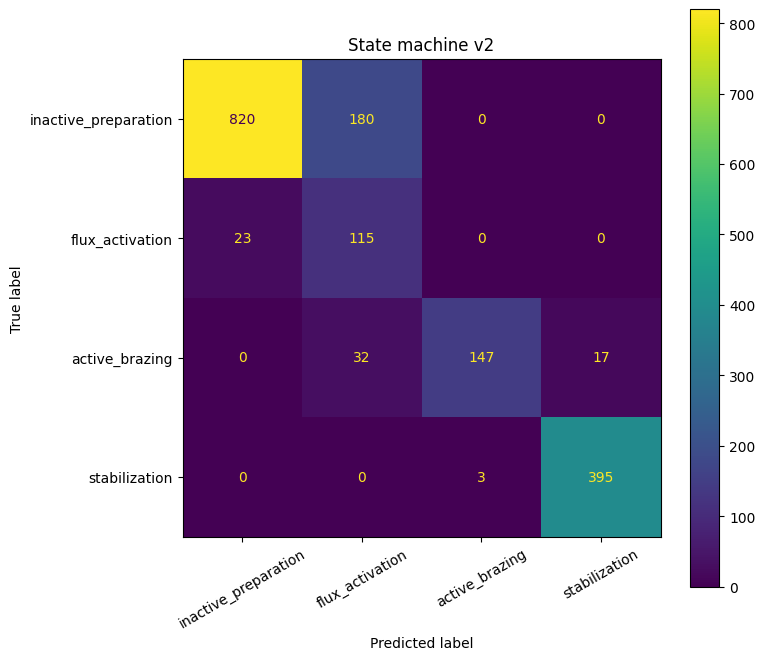

In [45]:
TRANSITION_RULES_V2 = {
    (0, 1): {
        "name": "inactive_to_flux",
        "min_confirm_frames": 12,
        "window_size": 20,
        "min_mean_prob": 0.55,
        "min_current_prob": 0.50,
    },
    (1, 2): {
        "name": "flux_to_active",
        "min_confirm_frames": 4,
        "window_size": 8,
        "min_mean_prob": 0.45,
        "min_current_prob": 0.40,
    },
    (2, 3): {
        "name": "active_to_stabilization",
        "min_confirm_frames": 6,
        "window_size": 10,
        "min_mean_prob": 0.50,
        "min_current_prob": 0.45,
    },
}

sm_v2_df = apply_state_machine_v2(
    pred_df,
    transition_rules=TRANSITION_RULES_V2,
)

sm_v2_metrics = evaluate_prediction_columns(
    sm_v2_df,
    pred_col="state_machine_v2_stage_id",
    title="State machine v2",
)

### metrics

In [46]:
metrics_comparison_v2 = pd.DataFrame([
    {
        "method": "raw",
        **{k: v for k, v in raw_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": f"majority_smoothing_w{SMOOTHING_WINDOW}",
        **{k: v for k, v in smooth_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v1",
        **{k: v for k, v in sm_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v2",
        **{k: v for k, v in sm_v2_metrics.items() if k != "confusion_matrix"},
    },
])

metrics_comparison_v2

,method,accuracy,macro_f1,weighted_f1
0,raw,0.874711,0.820934,0.889545
1,majority_smoothing_w5,0.877598,0.828993,0.892582
2,state_machine_v1,0.844111,0.798843,0.867352
3,state_machine_v2,0.852771,0.802374,0.873457


### timeline

In [47]:
def plot_stage_timeline_comparison_v2(
    df_raw: pd.DataFrame,
    df_smooth: pd.DataFrame,
    df_sm_v2: pd.DataFrame,
    video_id: str,
):
    raw_video_df = df_raw[df_raw["video_id"] == video_id].sort_values("timestamp_s")
    smooth_video_df = df_smooth[df_smooth["video_id"] == video_id].sort_values("timestamp_s")
    sm_v2_video_df = df_sm_v2[df_sm_v2["video_id"] == video_id].sort_values("timestamp_s")

    plt.figure(figsize=(15, 5))

    plt.scatter(
        raw_video_df["timestamp_s"],
        raw_video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        raw_video_df["timestamp_s"],
        raw_video_df["pred_stage_id"],
        s=12,
        label="raw",
        marker="x",
        alpha=0.35,
    )

    plt.plot(
        smooth_video_df["timestamp_s"],
        smooth_video_df["pred_stage_id_smooth"],
        label="majority smoothing",
        linewidth=2,
        alpha=0.8,
    )

    plt.plot(
        sm_v2_video_df["timestamp_s"],
        sm_v2_video_df["state_machine_v2_stage_id"],
        label="state machine v2",
        linewidth=2.8,
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"Stage timeline comparison v2 — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_state_machine_v2_timeline.png"
    plt.savefig(output_path, dpi=160)
    plt.show()

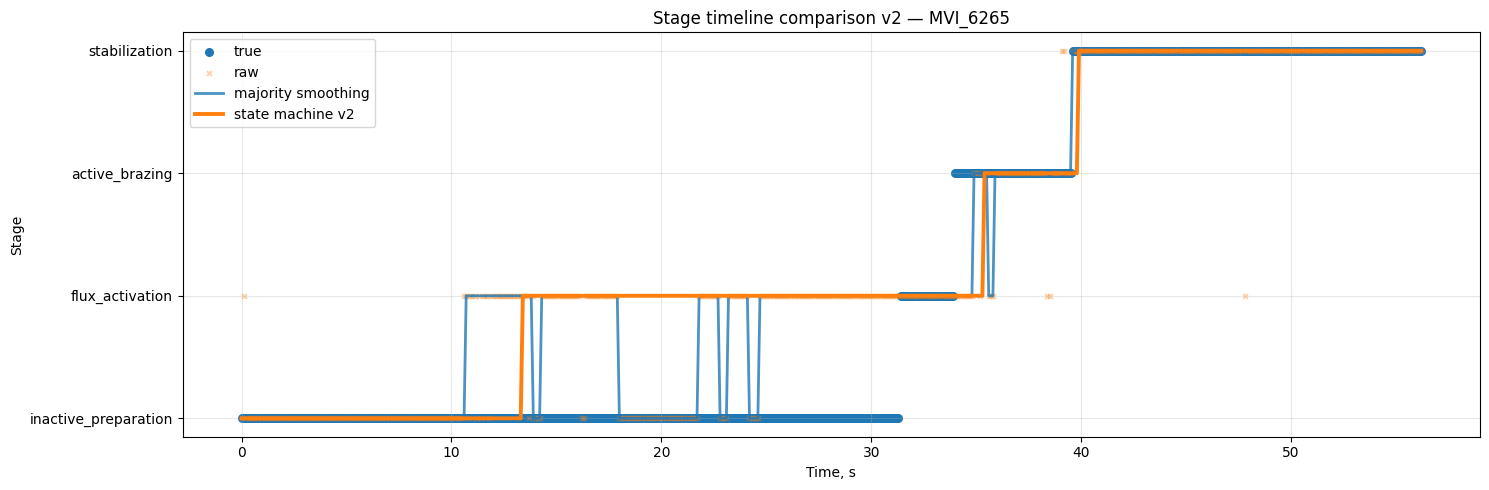

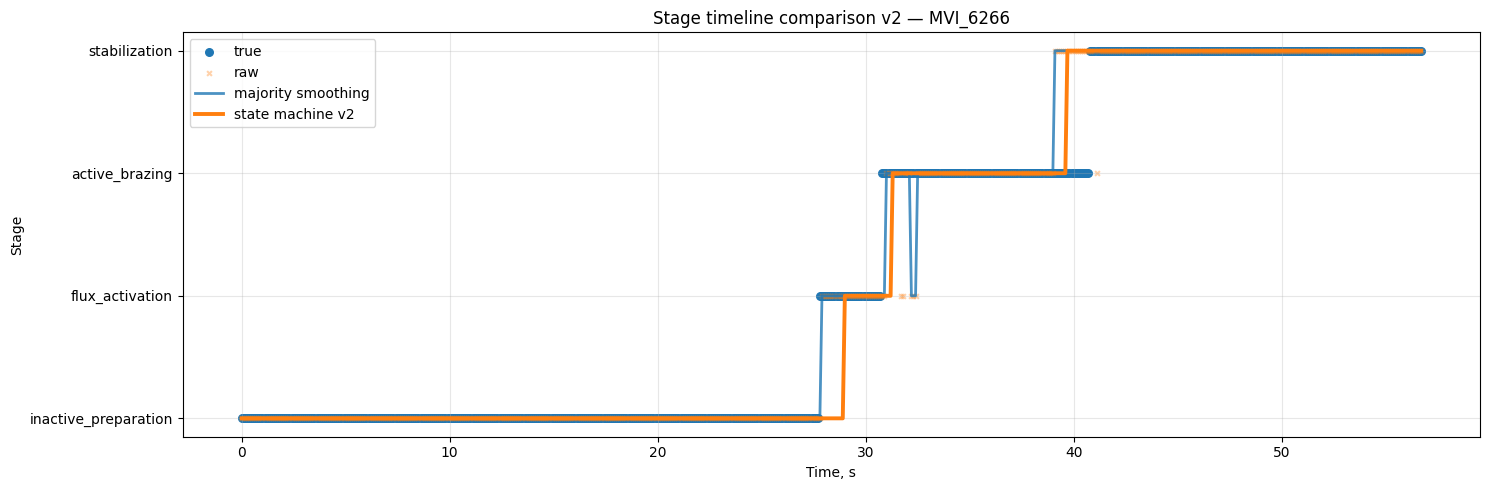

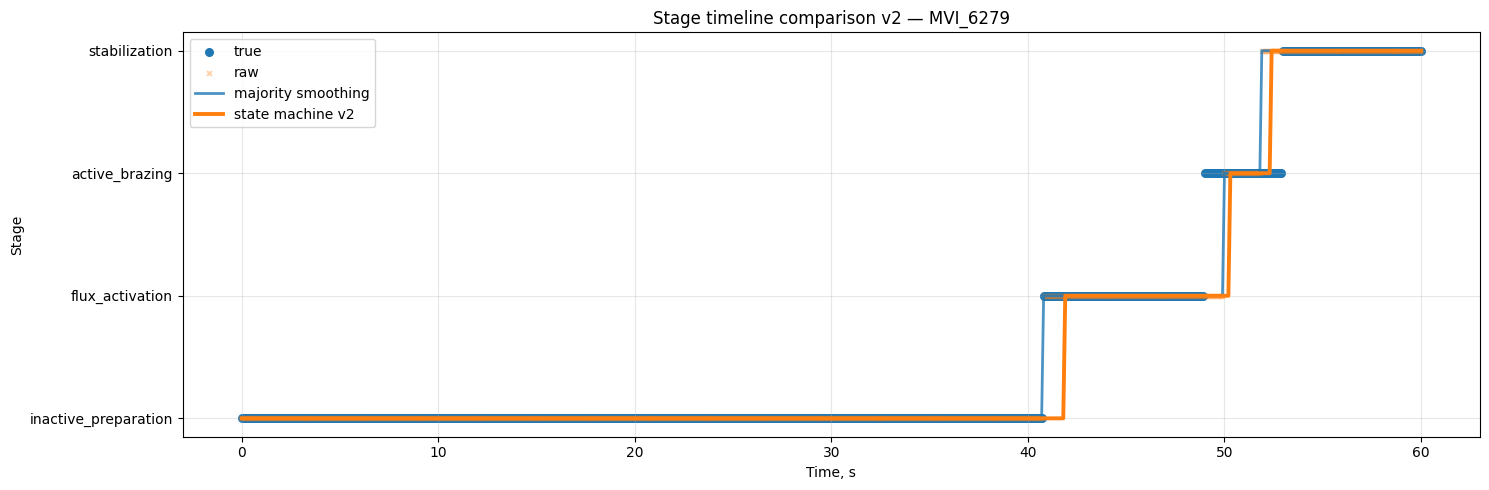

In [48]:
for video_id in sorted(pred_df["video_id"].unique()):
    plot_stage_timeline_comparison_v2(
        pred_df,
        smooth_df,
        sm_v2_df,
        video_id,
    )

## state machine v3

State machine v3
--------------------------------------------------------------------------------
accuracy:    0.8499
macro_f1:    0.8053
weighted_f1: 0.8716

                      precision    recall  f1-score   support

inactive_preparation     0.9817    0.8050    0.8846      1000
     flux_activation     0.3555    0.8913    0.5083       138
      active_brazing     0.9867    0.7551    0.8555       196
       stabilization     0.9519    0.9950    0.9730       398

            accuracy                         0.8499      1732
           macro avg     0.8189    0.8616    0.8053      1732
        weighted avg     0.9255    0.8499    0.8716      1732



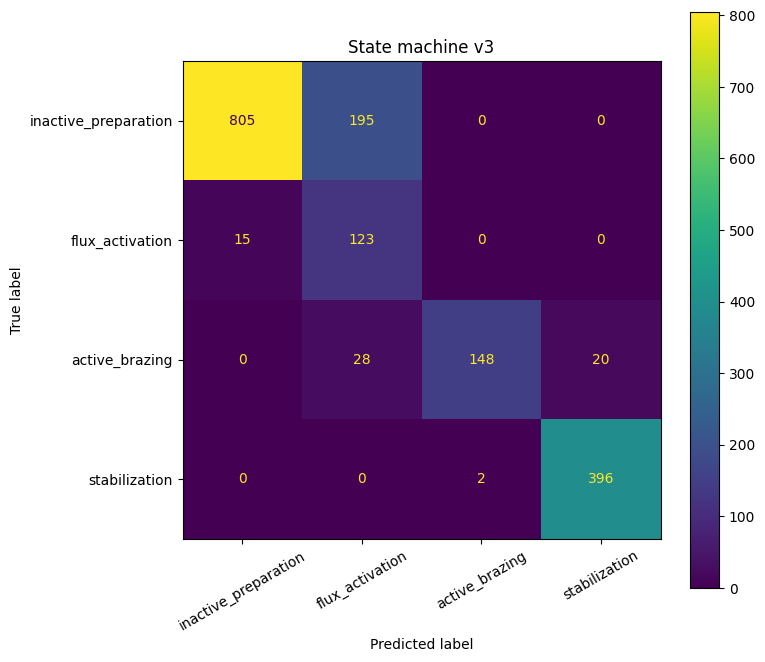

In [ ]:
TRANSITION_RULES_V3 = {
    (0, 1): {
        "name": "inactive_to_flux",
        "min_confirm_frames": 8,
        "window_size": 15,
        "min_mean_prob": 0.45,
        "min_current_prob": 0.40,
    },
    (1, 2): {
        "name": "flux_to_active",
        "min_confirm_frames": 3,
        "window_size": 6,
        "min_mean_prob": 0.40,
        "min_current_prob": 0.35,
    },
    (2, 3): {
        "name": "active_to_stabilization",
        "min_confirm_frames": 5,
        "window_size": 8,
        "min_mean_prob": 0.45,
        "min_current_prob": 0.40,
    },
}

sm_v3_df = apply_state_machine_v2(
    pred_df,
    transition_rules=TRANSITION_RULES_V3,
)

sm_v3_metrics = evaluate_prediction_columns(
    sm_v3_df,
    pred_col="state_machine_v2_stage_id",
    title="State machine v3",
)

In [ ]:
metrics_comparison_v3 = pd.DataFrame([
    {
        "method": "raw",
        **{k: v for k, v in raw_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": f"majority_smoothing_w{SMOOTHING_WINDOW}",
        **{k: v for k, v in smooth_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v1",
        **{k: v for k, v in sm_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v2",
        **{k: v for k, v in sm_v2_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v3",
        **{k: v for k, v in sm_v3_metrics.items() if k != "confusion_matrix"},
    },
])

metrics_comparison_v3

,method,accuracy,macro_f1,weighted_f1
0,raw,0.874711,0.820934,0.889545
1,majority_smoothing_w5,0.877598,0.828993,0.892582
2,state_machine_v1,0.844111,0.798843,0.867352
3,state_machine_v2,0.852771,0.802374,0.873457
4,state_machine_v3,0.849885,0.805336,0.871637


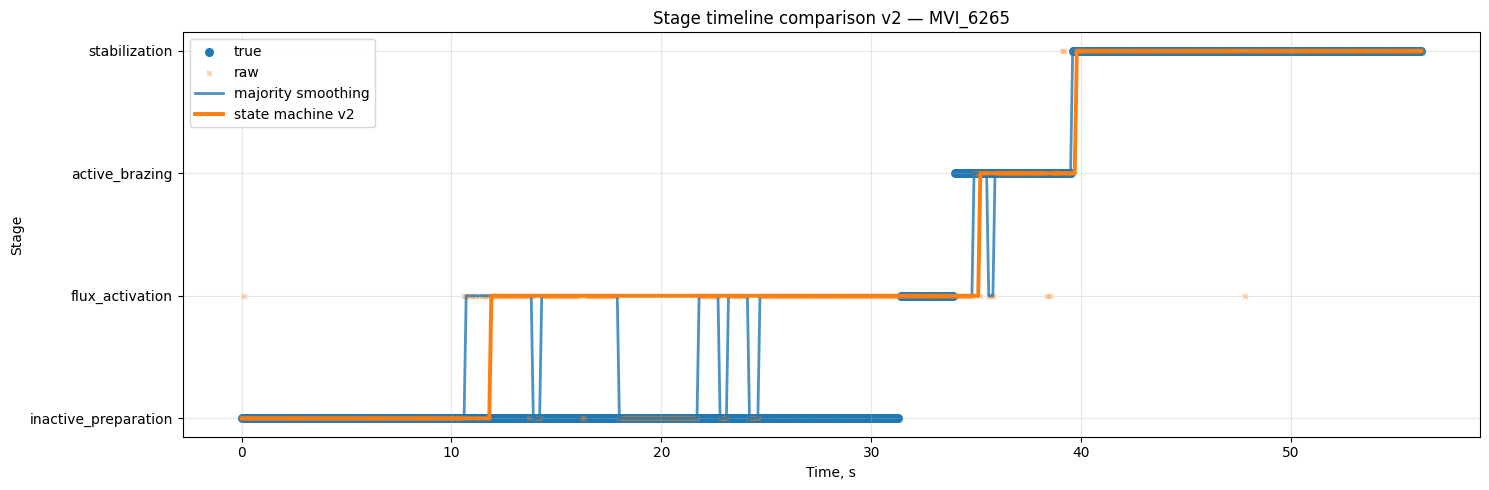

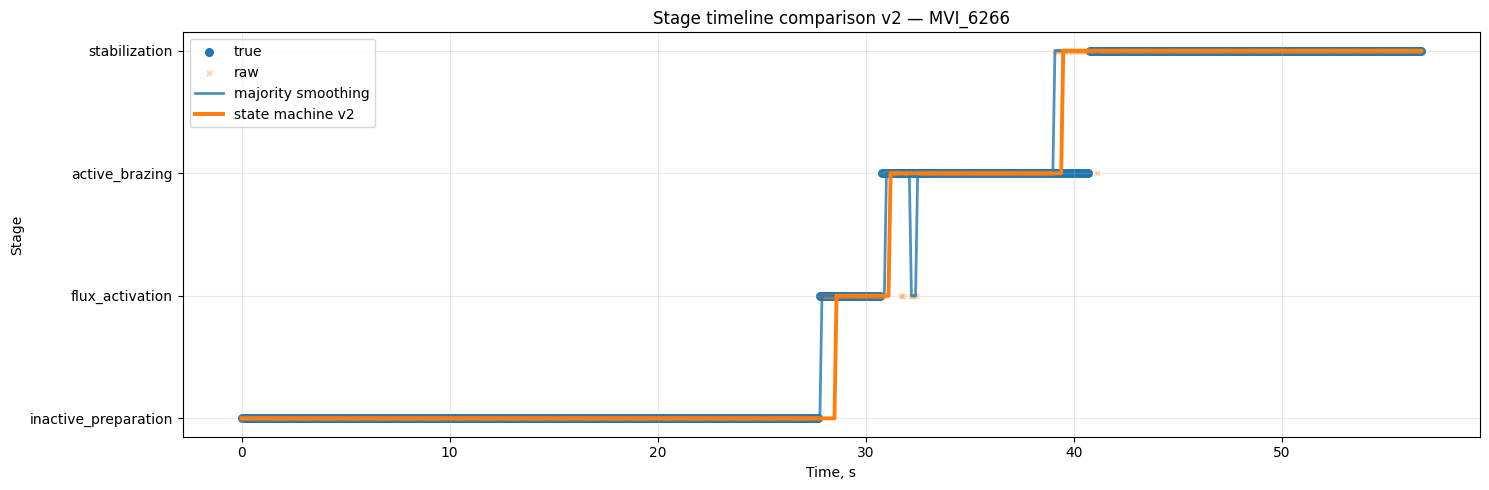

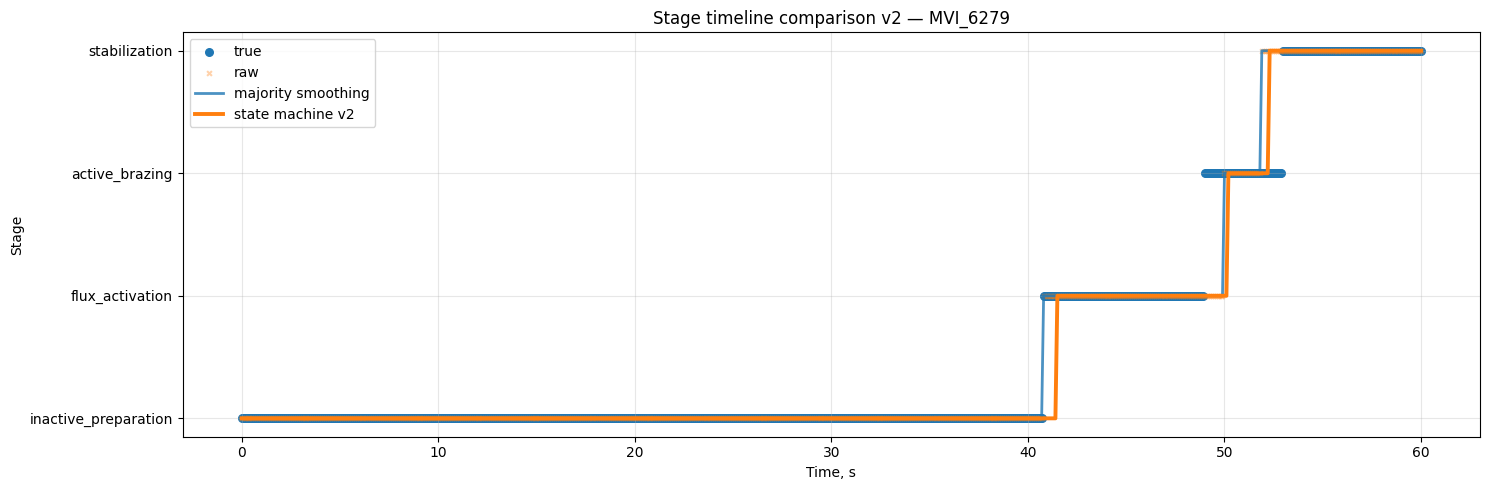

In [ ]:
for video_id in sorted(pred_df["video_id"].unique()):
    plot_stage_timeline_comparison_v2(
        pred_df,
        smooth_df,
        sm_v3_df,
        video_id,
    )

State machine v3
--------------------------------------------------------------------------------
accuracy:    0.8499
macro_f1:    0.8053
weighted_f1: 0.8716

                      precision    recall  f1-score   support

inactive_preparation     0.9817    0.8050    0.8846      1000
     flux_activation     0.3555    0.8913    0.5083       138
      active_brazing     0.9867    0.7551    0.8555       196
       stabilization     0.9519    0.9950    0.9730       398

            accuracy                         0.8499      1732
           macro avg     0.8189    0.8616    0.8053      1732
        weighted avg     0.9255    0.8499    0.8716      1732



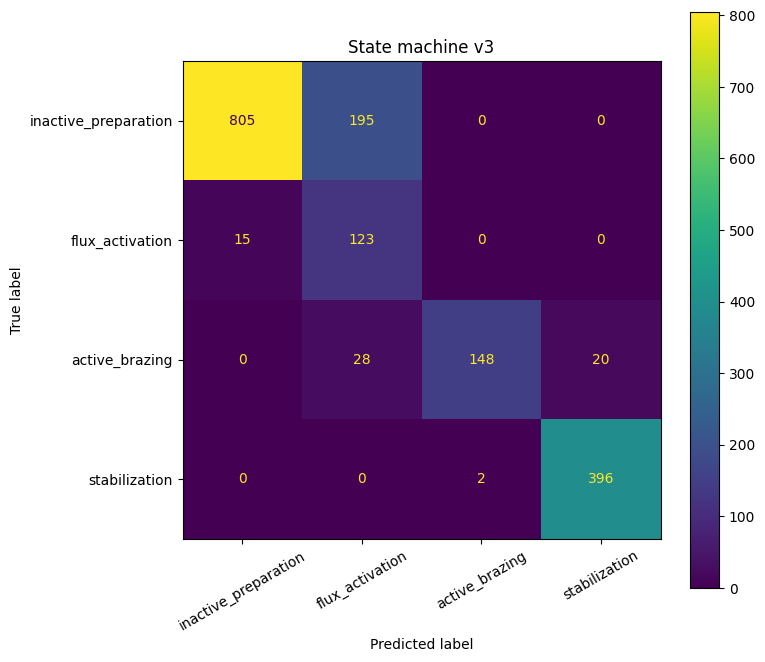

In [37]:
TRANSITION_RULES_V3 = {
    (0, 1): {
        "name": "inactive_to_flux",
        "min_confirm_frames": 8,
        "window_size": 15,
        "min_mean_prob": 0.45,
        "min_current_prob": 0.40,
    },
    (1, 2): {
        "name": "flux_to_active",
        "min_confirm_frames": 3,
        "window_size": 6,
        "min_mean_prob": 0.40,
        "min_current_prob": 0.35,
    },
    (2, 3): {
        "name": "active_to_stabilization",
        "min_confirm_frames": 5,
        "window_size": 8,
        "min_mean_prob": 0.45,
        "min_current_prob": 0.40,
    },
}

sm_v3_df = apply_state_machine_v2(
    pred_df,
    transition_rules=TRANSITION_RULES_V3,
)

sm_v3_metrics = evaluate_prediction_columns(
    sm_v3_df,
    pred_col="state_machine_v2_stage_id",
    title="State machine v3",
)

In [38]:
metrics_comparison_v3 = pd.DataFrame([
    {
        "method": "raw",
        **{k: v for k, v in raw_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": f"majority_smoothing_w{SMOOTHING_WINDOW}",
        **{k: v for k, v in smooth_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v1",
        **{k: v for k, v in sm_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v2",
        **{k: v for k, v in sm_v2_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v3",
        **{k: v for k, v in sm_v3_metrics.items() if k != "confusion_matrix"},
    },
])

metrics_comparison_v3

,method,accuracy,macro_f1,weighted_f1
0,raw,0.874711,0.820934,0.889545
1,majority_smoothing_w5,0.877598,0.828993,0.892582
2,state_machine_v1,0.844111,0.798843,0.867352
3,state_machine_v2,0.852771,0.802374,0.873457
4,state_machine_v3,0.849885,0.805336,0.871637


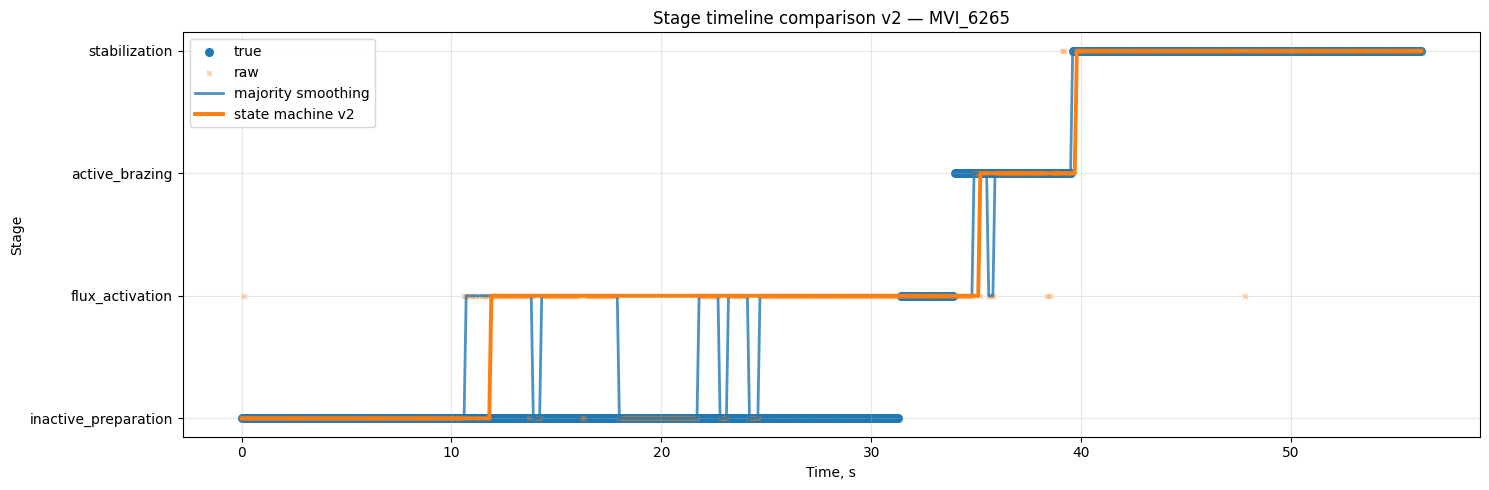

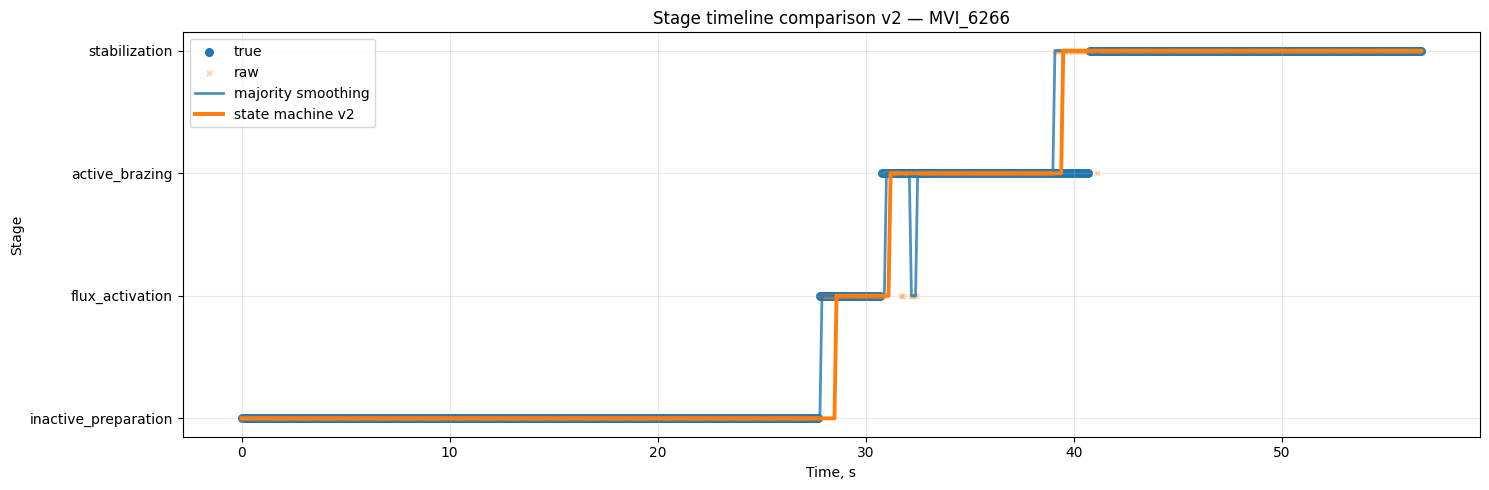

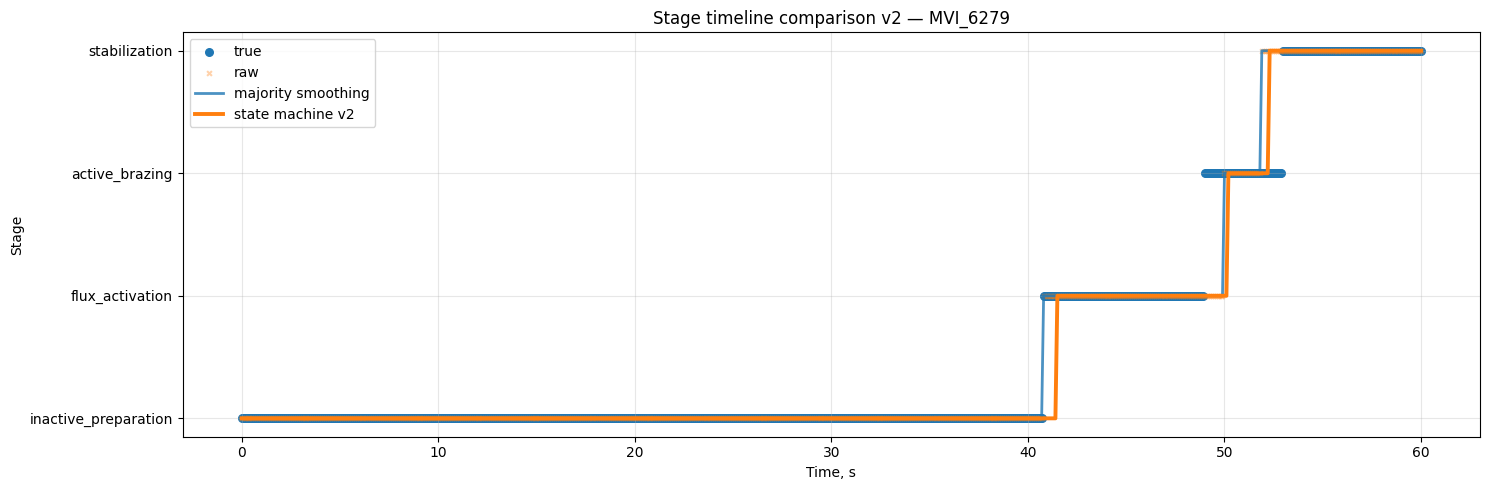

In [39]:
for video_id in sorted(pred_df["video_id"].unique()):
    plot_stage_timeline_comparison_v2(
        pred_df,
        smooth_df,
        sm_v3_df,
        video_id,
    )

## state machine v4

State machine v4
--------------------------------------------------------------------------------
accuracy:    0.8568
macro_f1:    0.8027
weighted_f1: 0.8753

                      precision    recall  f1-score   support

inactive_preparation     0.9652    0.8320    0.8937      1000
     flux_activation     0.3553    0.7826    0.4887       138
      active_brazing     0.9867    0.7551    0.8555       196
       stabilization     0.9519    0.9950    0.9730       398

            accuracy                         0.8568      1732
           macro avg     0.8148    0.8412    0.8027      1732
        weighted avg     0.9160    0.8568    0.8753      1732



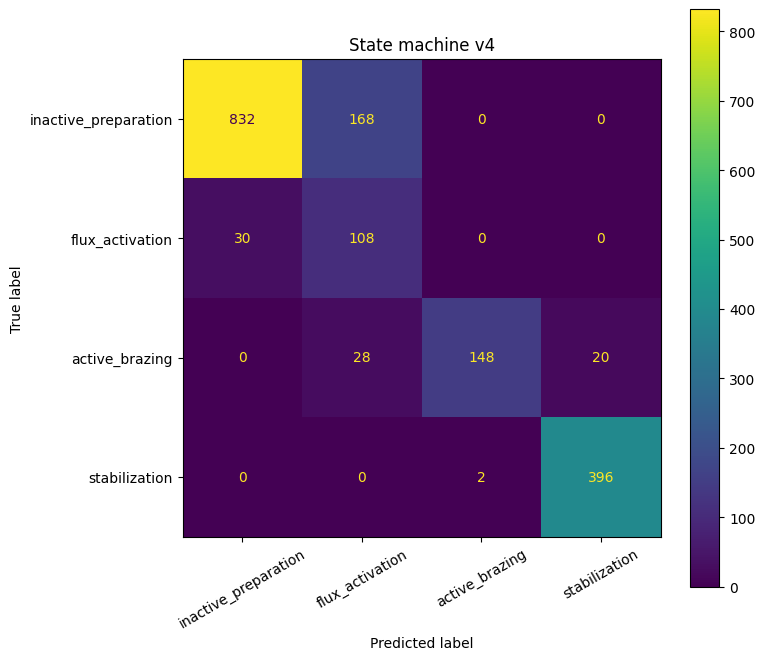

In [40]:
TRANSITION_RULES_V4 = {
    (0, 1): {
        "name": "inactive_to_flux",
        "min_confirm_frames": 15,
        "window_size": 25,
        "min_mean_prob": 0.55,
        "min_current_prob": 0.50,
    },
    (1, 2): {
        "name": "flux_to_active",
        "min_confirm_frames": 3,
        "window_size": 6,
        "min_mean_prob": 0.40,
        "min_current_prob": 0.35,
    },
    (2, 3): {
        "name": "active_to_stabilization",
        "min_confirm_frames": 5,
        "window_size": 8,
        "min_mean_prob": 0.45,
        "min_current_prob": 0.40,
    },
}

sm_v4_df = apply_state_machine_v2(
    pred_df,
    transition_rules=TRANSITION_RULES_V4,
)

sm_v4_metrics = evaluate_prediction_columns(
    sm_v4_df,
    pred_col="state_machine_v2_stage_id",
    title="State machine v4",
)

In [41]:
metrics_comparison_v4 = pd.DataFrame([
    {
        "method": "raw",
        **{k: v for k, v in raw_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": f"majority_smoothing_w{SMOOTHING_WINDOW}",
        **{k: v for k, v in smooth_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v1",
        **{k: v for k, v in sm_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v2",
        **{k: v for k, v in sm_v2_metrics.items() if k != "confusion_matrix"},
    },
    {
        "method": "state_machine_v3",
        **{k: v for k, v in sm_v3_metrics.items() if k != "confusion_matrix"},
    },
     {
        "method": "state_machine_v4",
        **{k: v for k, v in sm_v4_metrics.items() if k != "confusion_matrix"},
    },
])

metrics_comparison_v4

,method,accuracy,macro_f1,weighted_f1
0,raw,0.874711,0.820934,0.889545
1,majority_smoothing_w5,0.877598,0.828993,0.892582
2,state_machine_v1,0.844111,0.798843,0.867352
3,state_machine_v2,0.852771,0.802374,0.873457
4,state_machine_v3,0.849885,0.805336,0.871637
5,state_machine_v4,0.856813,0.802704,0.875301


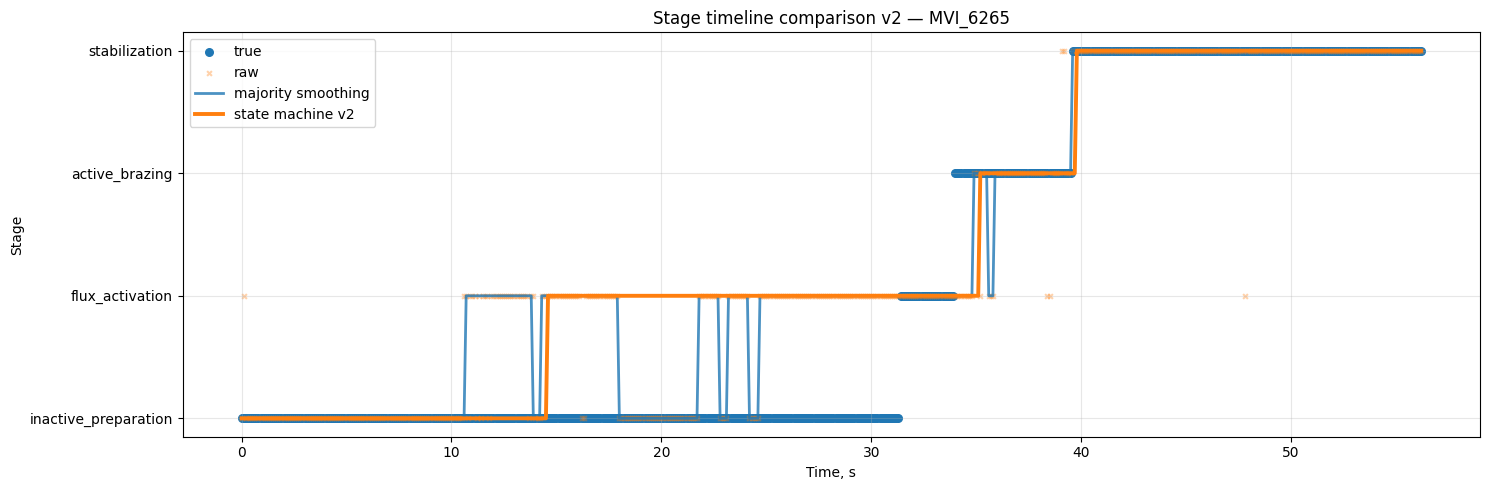

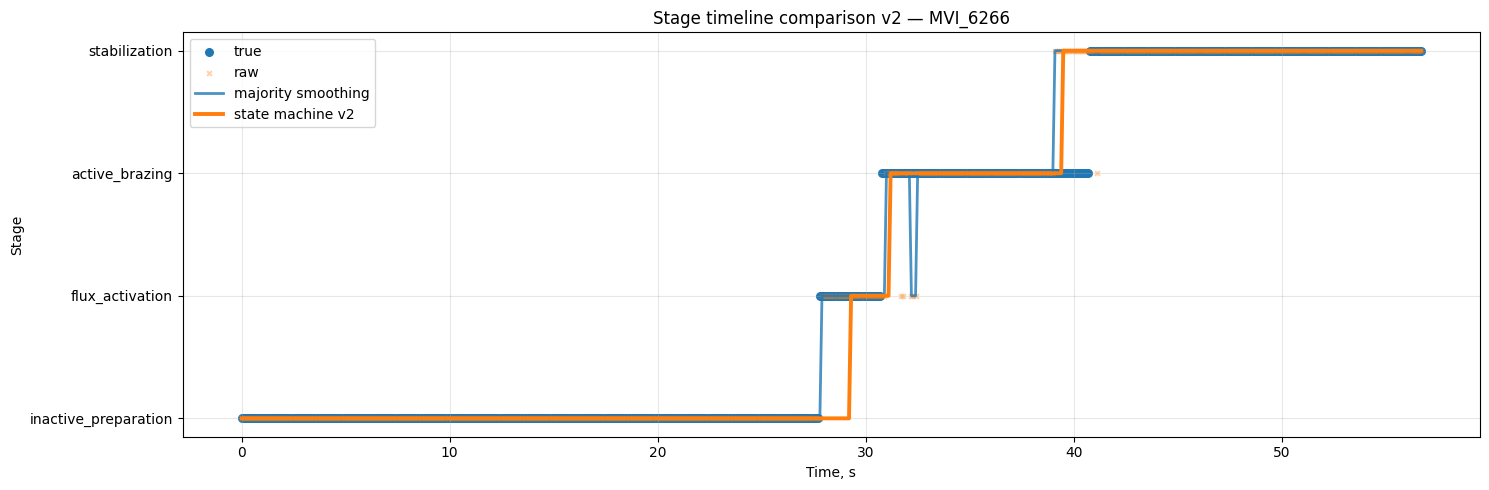

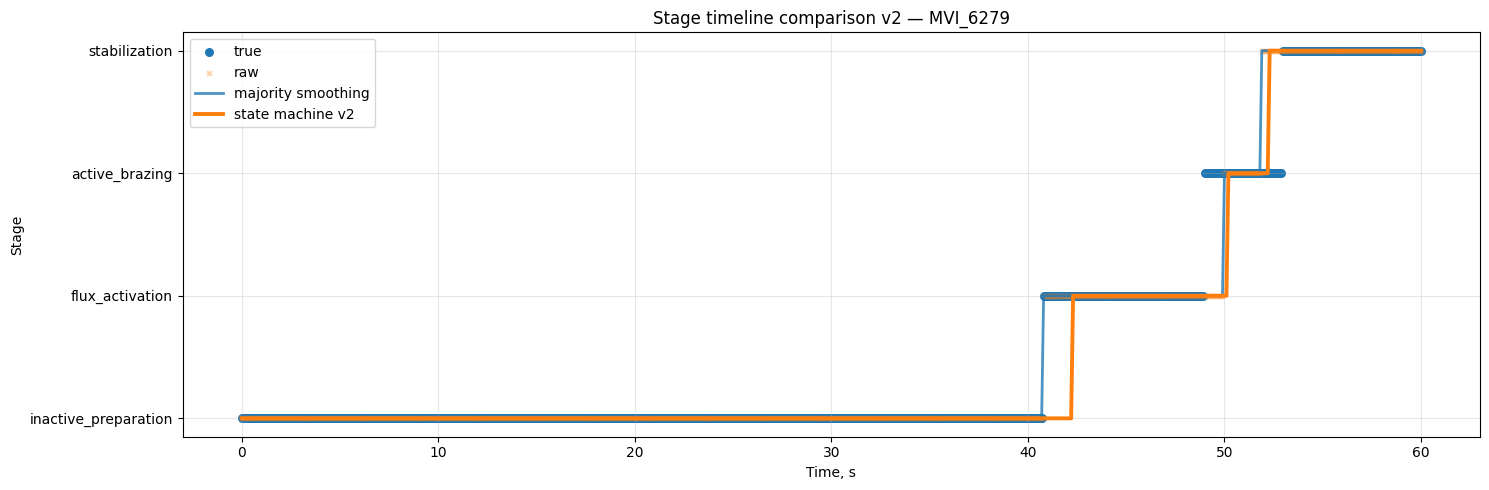

In [42]:
for video_id in sorted(pred_df["video_id"].unique()):
    plot_stage_timeline_comparison_v2(
        pred_df,
        smooth_df,
        sm_v4_df,
        video_id,
    )